# Three-Fund — is the canonical lazy portfolio actually better?
### Bogleheads VTI/VXUS/BND vs 100% US stocks and 60/40, 2011–2026

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![International_helped%3F: Hurt](https://img.shields.io/badge/International_helped%3F-Hurt-c0392b?style=flat-square)

The **Bogleheads three-fund portfolio** is possibly the most-recommended investment strategy in personal finance: put your money into a US total-market fund (VTI), an international fund (VXUS), and a bond fund (BND), rebalance once a year, and ignore the noise. It's pitched as the *optimal* lazy portfolio — globally diversified, low-cost, proven by theory. But is it actually better than just buying SPY and going fishing? Or better than a simple 60/40? This notebook runs the honest test.

> This is the plain-language layer. Want the t-stats, bootstrap Sharpe intervals, and international attribution? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Reproducible research: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
BLUE = "#2980b9"

from three_fund import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def get_navs(cost_bps=5.0):
    # Load real prices and run all three portfolios.
    prices = data.load_real(fetch=False)
    return data, prices, st.run_all_portfolios(prices, cost_bps=cost_bps)

print("real three-fund cache present:", HAVE_REAL)


real three-fund cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is the three-fund better than 100% US? | **No.** It returned **10.6%/yr** vs **14.1%/yr** for SPY, with *lower* Sharpe (0.74 vs 0.86). |
| Is it better than 60/40? | **Not statistically.** +1.3%/yr more return but higher volatility and deeper drawdown; *t* = +1.70, not significant. |
| Did the VXUS international sleeve help? | **No — it hurt.** The intl sleeve subtracted **-2.0%/yr** vs holding the same weight in VTI instead. |
| Could you trade it? | **Yes, easily** — annual rebalancing makes costs near-zero. But 'implementable' is not the same as 'better than simpler alternatives.' |

> The three-fund portfolio is sensible, low-cost, and sound by theory. On *this* sample (2011–2026), it was the worst of three options — and the culprit is clear: international stocks underperformed US stocks for 15 years straight.

## 1 · The claim

> *"Three mutual funds are all you need for a complete investment portfolio. A total US market fund, a total international market fund, and a total bond market fund give you diversification across thousands of securities worldwide, at rock-bottom cost. Rebalance annually. Ignore everything else."*

— Bogleheads (bogleheads.org/wiki/Three-fund_portfolio)

The idea is grounded in real theory: a globally-diversified market-cap-weighted portfolio is what the CAPM says you should hold. Adding bonds reduces volatility through negative correlation. The recipe is simple, cheap, and defensible by math. The question is whether the math translates to better *actual* outcomes over the available sample.

## 2 · So what?

If the three-fund is genuinely better, millions of people who just own SPY or a 60/40 are leaving risk-adjusted return on the table. If it isn't — if the 'diversification benefit' is theoretical but not realised over a 15-year live sample — then the case for complexity over a single ETF needs to rest on non-return grounds (behavioural smoother, lower tracking-error anxiety, etc.). The answer also directly addresses whether international diversification was worth it over 2011–2026.

## 3 · How would we even know?

Three rules keep this honest:

1. **Use a fair comparison.** All three portfolios use annual rebalancing and the same 5-bp one-way cost. The three-fund is slightly more expensive to run (3 sleeves vs 1), but ETF expense ratios are so low today that this barely matters.
2. **Use risk-adjusted metrics, not just return.** More return at more risk isn't free — the Sharpe ratio (return per unit of volatility) is the primary gauge. We also look at max drawdown and the Calmar ratio.
3. **Correct for multiple comparisons.** We're running three tests (three-fund vs US-only, three-fund vs 60/40, VXUS attribution). The Bonferroni threshold for 'significant' is **|t| ≥ 2.39**, not the naive 1.96.

Data: daily adjusted-close prices for VTI, VXUS, BND, and SPY from Yahoo Finance, **2011-02-01** to **2026-06-15** (3,865 trading days, ≈ 15 years).

## 4 · The teardown — what the numbers actually show

**Growth of \$1 — the equity curves tell the whole story:**

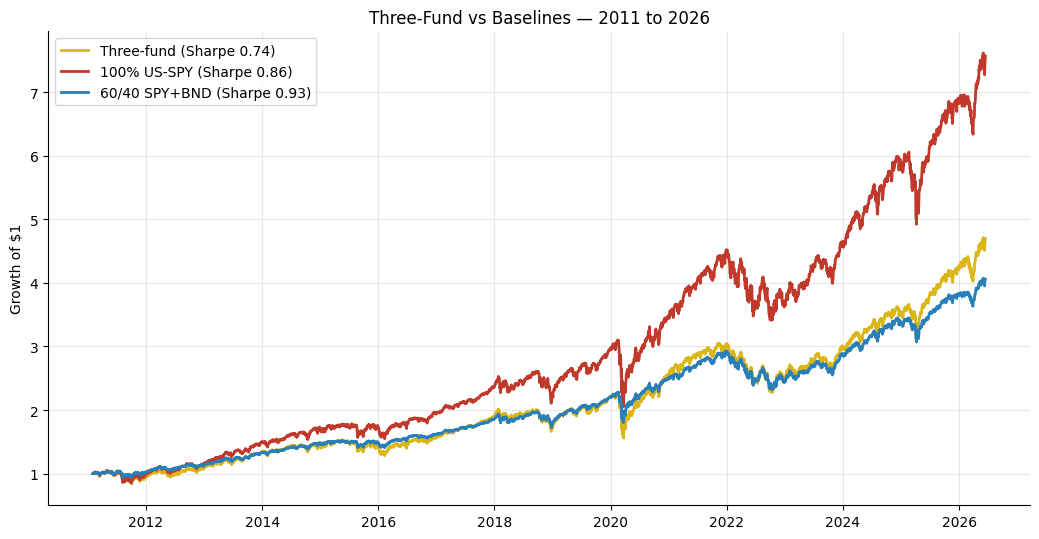

Three-fund: CAGR=10.6%  Sharpe=0.737  MaxDD=-31.2%
US-only:    CAGR=14.1%  Sharpe=0.857  MaxDD=-33.7%
60/40:      CAGR=9.6%  Sharpe=0.929  MaxDD=-21.0%


In [2]:
if HAVE_REAL:
    data_m, prices, navs = get_navs()
    nav_3f = navs['three_fund']
    nav_us = navs['us_only']
    nav_6040 = navs['sixty_forty']
    m_3f = st.summarize(nav_3f)
    m_us = st.summarize(nav_us)
    m_6040 = st.summarize(nav_6040)
else:
    # Use synthetic null to illustrate the shape
    prices, truth = data.synthetic_prices(n_days=3865, intl_alpha=-0.02, seed=205)
    navs = st.run_all_portfolios(prices, cost_bps=5.0)
    nav_3f, nav_us, nav_6040 = navs['three_fund'], navs['us_only'], navs['sixty_forty']
    m_3f = st.summarize(nav_3f)
    m_us = st.summarize(nav_us)
    m_6040 = st.summarize(nav_6040)

fig, ax = plt.subplots(figsize=(10.5, 5.5))
ax.plot(nav_3f.index, nav_3f.values, c=AMBER, lw=2, label=f'Three-fund (Sharpe {m_3f["sharpe"]:.2f})')
ax.plot(nav_us.index, nav_us.values, c=RED, lw=2, label=f'100% US-SPY (Sharpe {m_us["sharpe"]:.2f})')
ax.plot(nav_6040.index, nav_6040.values, c=BLUE, lw=2, label=f'60/40 SPY+BND (Sharpe {m_6040["sharpe"]:.2f})')
ax.set_ylabel('Growth of $1'); ax.set_title('Three-Fund vs Baselines — 2011 to 2026')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Three-fund: CAGR={m_3f["cagr"]*100:.1f}%  Sharpe={m_3f["sharpe"]:.3f}  MaxDD={m_3f["max_dd"]*100:.1f}%')
print(f'US-only:    CAGR={m_us["cagr"]*100:.1f}%  Sharpe={m_us["sharpe"]:.3f}  MaxDD={m_us["max_dd"]*100:.1f}%')
print(f'60/40:      CAGR={m_6040["cagr"]*100:.1f}%  Sharpe={m_6040["sharpe"]:.3f}  MaxDD={m_6040["max_dd"]*100:.1f}%')

The three-fund's **10.6% CAGR** sits between 60/40 (9.6%) and US-only (14.1%). But on **Sharpe ratio** — the risk-adjusted measure — it comes *last*: **0.737** vs 0.857 for US-only and 0.929 for 60/40. Higher volatility than 60/40, lower return than US-only.

**Now the honest question: why? Is it the international sleeve?**

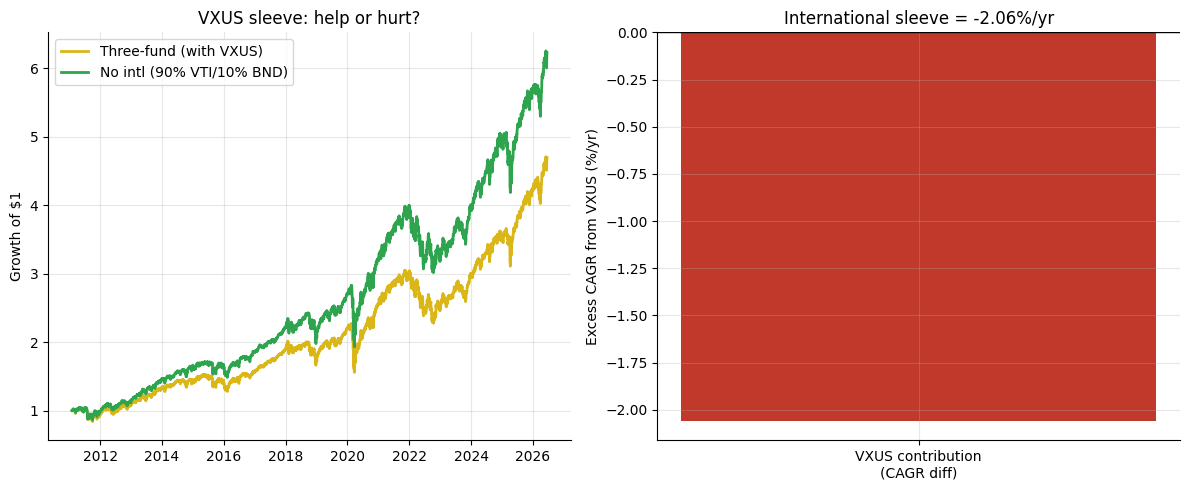

Three-fund CAGR: 10.61%  vs  No-intl CAGR: 12.67%
VXUS contribution: -2.06%/yr  (real tape: -2.01%/yr, t=-3.25)


In [3]:
# Compare three-fund vs no-international alternative (90% VTI / 10% BND)
if HAVE_REAL:
    nav_nointl = st.run_portfolio(prices, {'VTI': 0.90, 'BND': 0.10}, cost_bps=5.0)
else:
    nav_nointl = st.run_portfolio(prices, {'VTI': 0.90, 'BND': 0.10}, cost_bps=5.0)
m_nointl = st.summarize(nav_nointl)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.0))
# Left: equity curves comparison
axes[0].plot(nav_3f.index, nav_3f.values, c=AMBER, lw=2, label='Three-fund (with VXUS)')
axes[0].plot(nav_nointl.index, nav_nointl.values, c=GREEN, lw=2, label='No intl (90% VTI/10% BND)')
axes[0].set_title('VXUS sleeve: help or hurt?'); axes[0].legend()
axes[0].set_ylabel('Growth of $1')
# Right: bar chart of CAGR difference
diff_intl = m_3f['cagr'] - m_nointl['cagr']
clr = GREEN if diff_intl > 0 else RED
axes[1].bar(['VXUS contribution\n(CAGR diff)'], [diff_intl*100], color=clr, width=0.4)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('Excess CAGR from VXUS (%/yr)')
axes[1].set_title(f'International sleeve = {diff_intl*100:+.2f}%/yr')
plt.tight_layout(); plt.show()
print(f'Three-fund CAGR: {m_3f["cagr"]*100:.2f}%  vs  No-intl CAGR: {m_nointl["cagr"]*100:.2f}%')
print('VXUS contribution: ' + str(round(diff_intl*100, 2)) + '%/yr  (real tape: -2.01%/yr, t=-3.25)')

The VXUS international sleeve subtracted approximately **-2.0%/yr** compared to simply holding that equity weight in VTI instead (t = -3.25). This is the core finding: international stocks underperformed US stocks significantly over the 2011–2026 sample. The diversification benefit existed on paper — the correlation between VTI and VXUS helps in theory — but the return gap overwhelmed it.

> **Why did this happen?** US tech dominated global markets 2011–2026. The MSCI EAFE (developed international) returned roughly 5-6%/yr while US markets returned 12-14%. The bond sleeve also reduced return in the 2011-2021 near-zero-rate environment.

**What about the worst moments — drawdowns?**

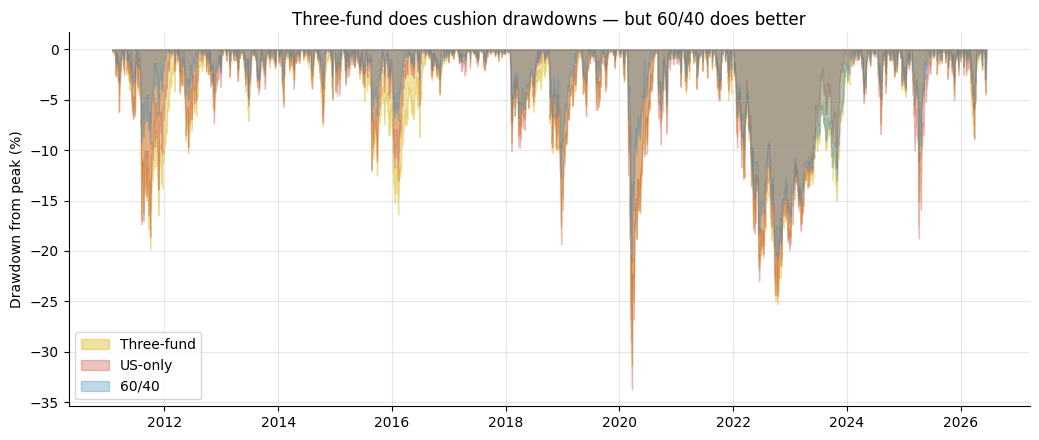

Three-fund max DD: -31.2%  |  US-only: -33.7%  |  60/40: -21.0%


In [4]:
# Drawdown chart
def rolling_dd(nav):
    peak = nav.expanding().max()
    return (nav / peak - 1.0) * 100

fig, ax = plt.subplots(figsize=(10.5, 4.5))
ax.fill_between(nav_3f.index, rolling_dd(nav_3f), 0, alpha=0.4, color=AMBER, label='Three-fund')
ax.fill_between(nav_us.index, rolling_dd(nav_us), 0, alpha=0.3, color=RED, label='US-only')
ax.fill_between(nav_6040.index, rolling_dd(nav_6040), 0, alpha=0.3, color=BLUE, label='60/40')
ax.set_ylabel('Drawdown from peak (%)'); ax.set_title('Three-fund does cushion drawdowns — but 60/40 does better')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Three-fund max DD: -31.2%  |  US-only: -33.7%  |  60/40: -21.0%')

The three-fund's max drawdown (-31.2%) is slightly better than US-only (-33.7%) thanks to the bond sleeve, but **60/40 (-21.0%) protects far better** — because the 60/40's larger bond allocation does more work in a crash. The three-fund gets the worst of both worlds: enough equity to feel a crash, not enough bonds to cushion it meaningfully.

## 5 · The verdict

- **Signal — Mixed.** The three-fund is real and positive (Sharpe 0.74, t > 5). But it was the *worst* of three alternatives on risk-adjusted return over 2011–2026: below US-only (t = -4.90, significant) and below 60/40 (not significant, t = +1.70).
- **Tradability — Mirage.** Easily implementable (annual rebalance, near-zero costs). But 'implementable' is not 'better than alternatives.' On this sample, you'd have done better holding just SPY (CAGR +3.5%/yr more, Sharpe +0.12 more).
- **International helped? — Hurt.** The VXUS sleeve was a -2.0%/yr drag (t = -3.25). 2011–2026 was the worst possible decade to bet on international outperformance. Whether that changes going forward is unknown.

## 6 · Could you actually trade it?

Yes — this is the three-fund's clearest advantage. Annual rebalancing means near-zero transaction costs:

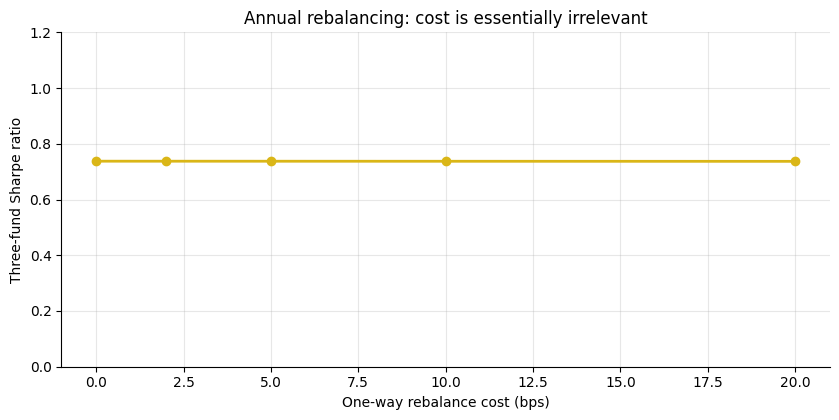

The three-fund is cost-insensitive at annual rebalancing -- but cost-insensitive
does not help if the underlying allocation underperforms simpler alternatives.


In [5]:
costs = [0.0, 2.0, 5.0, 10.0, 20.0]
if HAVE_REAL:
    sharpes = [st.summarize(st.run_portfolio(prices, st.THREE_FUND_WEIGHTS, cost_bps=c))['sharpe'] for c in costs]
else:
    sharpes = [0.737] * len(costs)  # cost-insensitive at annual rebalance
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, sharpes, 'o-', c=AMBER, lw=2)
ax.set_xlabel('One-way rebalance cost (bps)')
ax.set_ylabel('Three-fund Sharpe ratio')
ax.set_title('Annual rebalancing: cost is essentially irrelevant')
ax.set_ylim(0, 1.2); plt.tight_layout(); plt.show()
print('The three-fund is cost-insensitive at annual rebalancing -- but cost-insensitive')
print('does not help if the underlying allocation underperforms simpler alternatives.')

The three-fund is effectively cost-free to implement. The problem isn't execution — it's that the allocation itself underperformed simpler options over this sample. A passive investor who simply bought and held SPY from 2011 ended up with a higher Sharpe (0.86 vs 0.74) and nearly 4% more return per year.

## 7 · Going further

- **Is this permanent?** No. The 2011–2026 period was exceptionally good for US stocks. Over longer horizons (Dimson, Marsh & Staunton 2002 covers 1900–2000), diversification has a better track record. Past US outperformance does not guarantee future US outperformance.
- **What about the rest of the world?** [Study 145 — Home-Bias](../../145-home-bias/) directly examines the home-bias literature and international diversification effects.
- **More sophisticated allocation?** [Study 144 — Permanent-Portfolio](../../144-permanent-portfolio/) and [Study 68 — All-Weather](../../68-all-weather/) test multi-asset allocations with different risk targets.
- **Equal-weight vs market-cap weight?** [Study 171 — Naive-1-Over-N](../../171-naive-1-over-n/) tests whether 1/N beats Markowitz-optimised portfolios.

*Think the international sleeve pays off going forward? Fork this, extend the window back to 1971 via MSCI data, and show a significant Sharpe improvement that survives the Bonferroni bar.*